# Terrestrial Water Storage: Computing GRACE(-FO) basin averages and associated uncertainties from the JPL-Mascon data
#### written by: Felix Landerer (landerer@jpl.nasa.gov) and Munish Sikka (munish.sikka@jpl.nasa.gov); 
#### Version 1.0 [Aug-2023]

In [1]:
import sys
import os
if 'google.colab' in sys.modules:
    print("Running in Colab. Preparing NASA-GRACE/GRACE-Analysis-Tutorials environment...")
    
    # 1. Install system libraries quietly
    !apt-get install -y libgdal-dev libproj-dev proj-data proj-bin libgeos-dev > /dev/null 2>&1
    
    # 2. Install Python packages while pinning fsspec to keep Colab happy
    # This prevents the red error message
    !pip install -q \
        fsspec==2025.3.0 \
        cartopy \
        geopandas \
        netcdf4 \
        h5netcdf \
        statsmodels \
        s3fs
    
    # 3. Clone the repository
    repo_url = "https://github.com/NASA-GRACE/GRACE-Analysis-Tutorials.git"
    repo_dir = "GRACE-Analysis-Tutorials"
    
    if not os.path.exists(repo_dir):
        # Clone if it's the first time running this session
        !git clone {repo_url}
    else:
        # If folder exists, just pull the latest code to ensure it's up to date
        print("Repository already exists. Syncing latest changes...")
        %cd {repo_dir}
        !git pull origin main
    
    # 4. Path Configuration
    # Ensure we are actually inside the directory
    if os.getcwd() != f"/content/{repo_dir}":
        os.chdir(f"/content/{repo_dir}")
     
    # 5. Add the current directory to the system path as a backup
    if f"/content/{repo_dir}" not in sys.path:
        sys.path.append(f"/content/{repo_dir}")
        
    print("Setup complete! The environment is stable and ready.")
else:
    print("Running locally.")

Running locally.


In [2]:
import time
from netCDF4 import Dataset, date2index
from datetime import datetime, date

import xarray as xr
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib.dates as mdates

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shapefile
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
import os

import sys
import os.path
import subprocess
import netCDF4
import math
import csv

#import s3fs
import copy
import json, copy
from pandas import DataFrame
from osgeo import gdal, ogr, osr
import glob
import grace_user_functions as grace_func
gdal.UseExceptions()  # Enable GDAL exceptions for error handling

## Step 1: Load GRACE/GRACE-FO data and basin masks / shapefiles

In [3]:
start_date = "2002-04-01"
user_end_date = "2100-12-31" #set to future date to read max timestamp data from nc file, if users want a smaller time period compared to entire grace time coverage they can edit this date

file_access_type = 'local'
#file_access_type = 'cloud'
ShortName_mass = 'TELLUS_GRAC-GRFO_MASCON_CRI_GRID_RL06.1_V3' # PO.DAAC's 'short name' is an identifier for the dataset
grace_file_pattern = r'GRACE_RESOURCES/GRCTellus.JPL.*.nc'
grace_files = glob.glob(grace_file_pattern)
if grace_files:
    grace_filename = max(grace_files)
else:
    print("No matching files found in the directory.")
print(grace_filename)

#grace_filename ='GRCTellus.JPL.200204_202510.GLO.RL06.3M.MSCNv04CRI.nc' #edit to the filename user wants to read

if file_access_type.lower() == 'local':
    print("Reading GRACE mascon dataset from local disk")
    try:
        dataset = xr.open_dataset((grace_filename))
    except FileNotFoundError:
        print('Error: The file does not exist.')
elif file_access_type.lower() == "cloud":
    print("Reading GRACE mascon dataset from PODAAC Cloud")
    import s3fs
    grace_nc_file = os.path.basename(grace_filename)
    dataset = grace_func.read_grace_dataset(ShortName_mass,grace_nc_file)	
else:
    print("Unknown file access type.")

# read scale factors from the mascon dataset
scale_factor_xarray = dataset["scale_factor"]
scale_factor = scale_factor_xarray.to_numpy()

GRACE_RESOURCES\GRCTellus.JPL.200204_202603.GLO.RL06.3M.MSCNv04CRI.nc
Reading GRACE mascon dataset from local disk


1.1 Take a look at the dataset contents that were just loaded:

In [4]:
dataset

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 255, lat: 360, lon: 720, bounds: 2)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2002-04-17T12:00:00 ... 2026-03-...
  * lat            (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon            (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.8 359.2 359.8
Dimensions without coordinates: bounds
Data variables:
    lwe_thickness  (time, lat, lon) float64 529MB ...
    uncertainty    (time, lat, lon) float64 529MB ...
    lat_bounds     (lat, bounds) float64 6kB ...
    lon_bounds     (lon, bounds) float64 12kB ...
    time_bounds    (time, bounds) datetime64[ns] 4kB ...
    land_mask      (lat, lon) float64 2MB ...
    scale_factor   (lat, lon) float64 2MB nan nan nan nan ... nan nan nan nan
    mascon_ID      (lat, lon) float64 2MB ...
    GAD            (time, lat, lon) float64 529MB ...
Attributes: (12/53)
    Conventions:                   CF-1.6, ACDD-1.3, ISO 8601
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    title:                         JPL GRACE and GRACE-FO MASCON RL06.3Mv04 CRI
    summary:                       Monthly gravity solutions from GRACE and G...
    keywords:                      Solid Earth, Geodetics/Gravity, Gravity, l...
    ...                            ...
    C_30_substitution:             TN-14; Loomis et al., 2019, Geophys. Res. ...
    user_note_1:                   The accelerometer on the GRACE-B spacecraf...
    user_note_2:                   The accelerometer on the GRACE-D spacecraf...
    journal_reference:             Watkins, M. M., D. N. Wiese, D.-N. Yuan, C...
    CRI_filter_journal_reference:  Wiese, D. N., F. W. Landerer, and M. M. Wa...
    date_created:                  2026-05-04T10:05:09Z

In [5]:
# determine end date based on nc file data and user defined limit
file_end_time = dataset.time.max().values
if user_end_date:
    # Convert string to a comparable timestamp
    cutoff = pd.to_datetime(user_end_date)
    # Use min() to pick whichever comes first: the user's limit or the file's limit
    end_date = min(pd.to_datetime(file_end_time), cutoff)
else:
    end_date = file_end_time
print(f'GRACE data read till {end_date}')

GRACE data read till 2026-03-16 12:00:00


1.2 Assign variables to compute water-equivalent heights:

In [6]:
lwe_thickness_subset = dataset["lwe_thickness"].sel(
    time=slice(start_date, end_date)).values
tdim, ydim, xdim = lwe_thickness_subset.shape

sig_lwe = dataset["uncertainty"].sel(
    time=slice(start_date, end_date)).values

1.3 Read a basin mask from a shape file (Note: other shapefiles can be used):

In [7]:
# link for shape file used in this script:
# https://www.bafg.de/SharedDocs/ExterneLinks/GRDC/wmobb_shp_zip.html?nn=201388 (shape file used in this code)
#place the shape file in local dir and use absoulte path 
shp = "GRACE_RESOURCES/wmobb_basins.shp"
layer_name = 'COLORADO (also COLORADO RIVER)'
[marr,bbox] = grace_func.read_shapefile_multilayers(shp,xdim,ydim,layer_name)

In [8]:
# mask and basin_area will be in N-S and -180 to 180 format. We need to shift , circroll to match it to GRACE(-FO) grid:
lat_vector = dataset.lat[:].copy()
lon_vector = dataset.lon[:].copy()
flip_lat = lat_vector[0] < lat_vector[-1]

data_res = abs(lon_vector[2 ] - lon_vector[1]) #resolution of dataset
indexes_to_shift = int(360 / (2 * data_res)) # no of global longitude divided by degree resolution; /2 gives mid point around which shift is done.

# determine if longitudes starts at 0 and goes to n then circshift or roll the grid and longitude array  
shift_lon = np.max(lon_vector) > 180

1.3.1 Compute weighted area for this region_mask

In [9]:
# The grid area associated with each grid is uniform in longitude. 
# We only need to calculate the grid area for one longitude.
# Check latitude array and compute resolution
if len(lat_vector.data) < 2:
    raise ValueError("Latitude array must have at least 2 elements")
resolution = np.abs(lat_vector.data[0] - lat_vector.data[1])
area_weights = grace_func.area(lat_vector.data, resolution).reshape(1,-1)
area_weights = np.transpose(area_weights)
no_of_lon = lon_vector.data.size
area_matrix = np.repeat(area_weights,no_of_lon,axis=1)

In [10]:
# apply mask on global area weights
basin_area = np.multiply(area_weights,marr)

In [11]:
region_mask = grace_func.shift_to_GRACE_orientation(shift_lon,flip_lat,marr,indexes_to_shift,1)
ma = grace_func.shift_to_GRACE_orientation(shift_lon,flip_lat,basin_area,indexes_to_shift,1)

## Step 2: Calculate mean over selected region

In [12]:
# apply scaling factor to lwe_thickness
lwe_thickness_scaled = lwe_thickness_subset * scale_factor
print(lwe_thickness_scaled.shape)
print(ma.shape)

# build effective weights (mask + area)
effective_weights = np.where(region_mask == 0, 0, ma)  # (y, x)

# remove pixels where data is NaN OR mask is zero
valid = (~np.isnan(lwe_thickness_scaled)) & (effective_weights > 0)

# expand weights to 3D for broadcasting
w3 = effective_weights[None, :, :]

# compute weighted mean per timestep, ignoring invalid pixels
num = np.sum(np.where(valid, lwe_thickness_scaled * w3, 0.0), axis=(1, 2))
den = np.sum(np.where(valid, w3, 0.0), axis=(1, 2))

regional_timeseries = num / den

(255, 360, 720)
(360, 720)


## Step 3: plot basin-mean, and a map of the most recent monthly TWS anomaly map

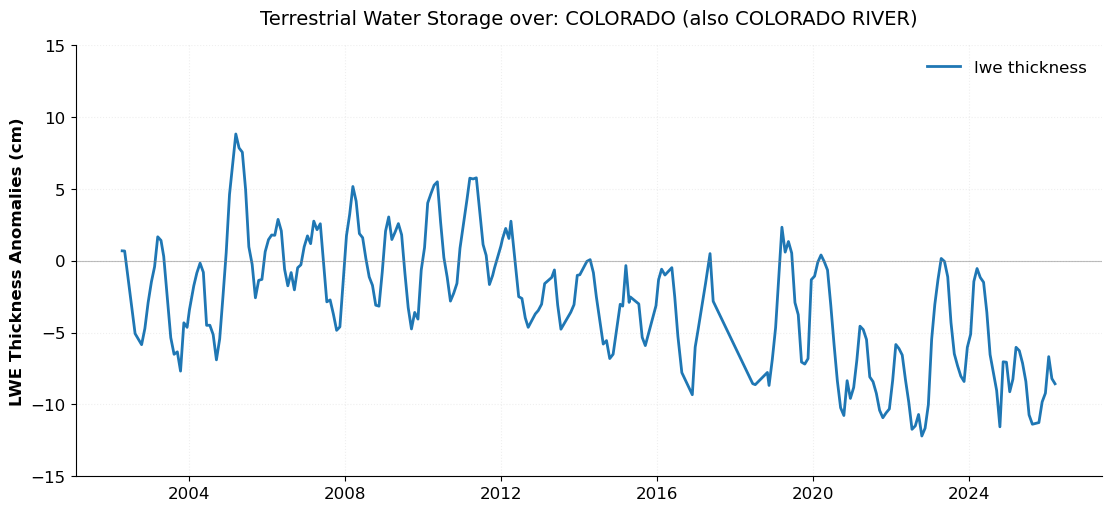

In [13]:
# plot monthly timeseries (#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/)
timesteps = dataset["time"].sel(
    time=slice(start_date, end_date)).values
plot_title_str = 'Terrestrial Water Storage over: ' + layer_name
xmin = timesteps[0]
xmax = timesteps[-1]
ymin = -15
ymax = 15
yticks = np.arange(ymin, ymax+1,2)

plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
# Plot the data
ax.plot(timesteps, regional_timeseries, color='tab:blue', label='lwe thickness',lw=2)
ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('LWE Thickness Anomalies (cm)', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
ax.set_ylim([ymin, ymax])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)
#fig.savefig(f"{river_basin}_lineplot.png",dpi=300)

<Figure size 1000x800 with 0 Axes>

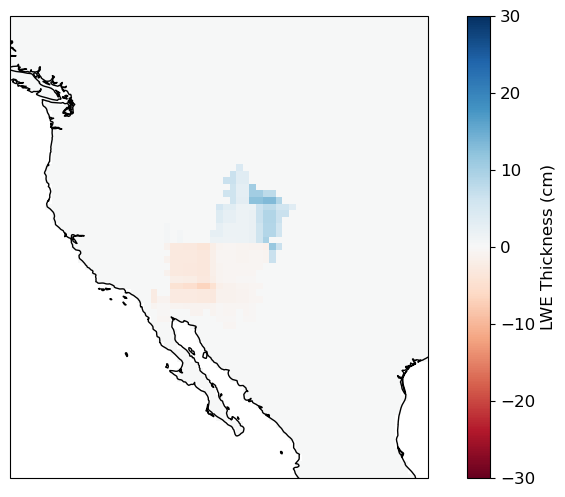

In [14]:
# plot the region on a map
lon_min, lat_min, lon_max, lat_max = bbox
lon_span = lon_max - lon_min
lat_span = lat_max - lat_min

pad_lon = 0.9 * lon_span
pad_lat = 0.9 * lat_span

min_lon = lon_min - pad_lon
max_lon = lon_max + pad_lon
min_lat = max(-90.0, lat_min - pad_lat)
max_lat = min(90.0,  lat_max + pad_lat)

region_grid=np.multiply(lwe_thickness_scaled[0,:,:],region_mask)
#plot the map of the region along with desired extent in the background
dpi = 96
fig = plt.figure(figsize=(1000 / dpi , 800 / dpi), dpi=dpi)

# set up the plot
proj = ccrs.PlateCarree()
f, ax = plt.subplots(subplot_kw=dict(projection=proj),figsize = (10,6))
h = ax.pcolormesh(lon_vector, lat_vector, region_grid, transform=proj, cmap='RdBu',vmin=-30,vmax=30)
ax.coastlines()

cbar = plt.colorbar(h, ax=ax, orientation='vertical', pad=0.05, aspect=20)
cbar.set_label('LWE Thickness (cm)')

# Set map extent 
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Show the plot
plt.show()

#plt.savefig(output_plot_filename,  dpi=dpi)# in case we wish to save the plot

## Step 4: Uncertainty Estimate over the Region of Interest

#### Source: https://grace.jpl.nasa.gov/data/get-data/jpl_global_mascons/
#### For the JPL Mascons, measurement uncertainties are provided on a 0.5 degree grid in latitude and longitude for each monthly grid. Importantly, the uncertainties provided are the uncertainty values for EACH independent mascon, which are roughly 300km in spatial extent. Thus, there are only 4,551 independent estimates of uncertainty represented for each monthly grid over entire globe. This needs to be taken into account when computing the uncertainty of basin means.

#### The mascon IDs for points in our regional analysis in this tutorial are determined using file containing mascon IDs.

#### A detailed description of the uncertainty derivation is found in Wiese, Landerer and Watkins (2016). https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2016WR019344

In [15]:
#read the grid of mascon IDs from the mascon dataset
mascon_ID= dataset["mascon_ID"]
mscID=mascon_ID.to_numpy()

#### These gridded uncertainties are not the uncertainties associated with a single 0.5 degree pixel (which would be much higher!). 
#### To derive the scaled uncertainty estimates, we scale the formal covariance matrix over the ocean to match the error we see when comparing the GRACE/GRACE-FO data to in-situ ocean bottom pressure data. 
#### Over land, the formal uncertainty is scaled to roughly match uncertainty estimates that we derive using methods described in Wahr et al., (2006). 
#### The provided estimates of uncertainty are conservative. Since we implement a Kalman filter in our JPL-mascon solution process to link adjacent months together temporally, monthly solutions both at the very beginning and end of the time series have slightly larger uncertainties compared to monthly solutions in the middle of the time series. This also means that as the time series is extended with newer observations, the uncertainty estimates of recent months will change (typically: become smaller) as more data are added, until a floor is reached. Error estimates typically stabelize approx. 6 months away from the time series boundaries.

In [16]:
# find uncertainty values within the basin mask:
sig_lwe_ma , maA = grace_func.compute_regional_uncertainty(sig_lwe, ma, mscID) 

# RSS (Root Sum of Squares) for total regional error
# Divide by total area to get LWE:
bsn_sig = (np.sqrt(np.sum(np.square(sig_lwe_ma),axis=1)))/np.sum(maA)

In [17]:
lower_bound = regional_timeseries - bsn_sig
upper_bound = regional_timeseries + bsn_sig

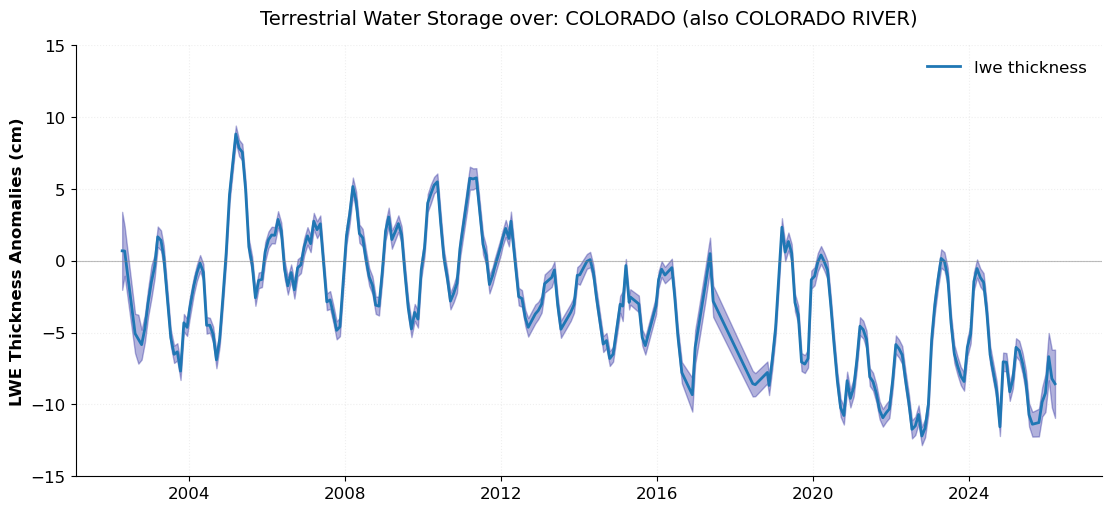

In [18]:
# plot monthly timeseries (#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/)
xmin = timesteps[0]
xmax = timesteps[-1]
ymin = -15
ymax = 15
yticks = np.arange(ymin, ymax+1,2)
region_color='darkblue'
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
ax.plot(timesteps, regional_timeseries, color='tab:blue', label='lwe thickness',lw=2)
ax.fill_between(timesteps, lower_bound, upper_bound, alpha=0.3, edgecolor=region_color, facecolor=region_color)
ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('LWE Thickness Anomalies (cm)', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
ax.set_ylim([ymin, ymax])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)